# 🎯 Tema 22: Máquinas de Soporte Vectorial (SVM) y Kernels

¡Bienvenido/a a la clasificación mediante geometría en alta dimensión!

En el módulo anterior utilizamos KNN, un algoritmo basado en la "cercanía" física de los datos. Hoy daremos un salto matemático gigante con las **Máquinas de Soporte Vectorial (SVM)**. El objetivo de una SVM es trazar una línea (o frontera) que no solo separe nuestras categorías, sino que lo haga dejando el **mayor margen de seguridad posible** entre ellas.

## 🚀 Contenido del Cuaderno

1. **Fundamentos de SVM:** Hiperplanos y Márgenes.
2. **El "Truco del Kernel":** Transformando datos en múltiples dimensiones.
3. **Proyecto Práctico:** Retención de Talento (RRHH).
4. **Evaluación de Kernels:** Lineal, Polinómico, RBF y Sigmoid.
5. **Nivel Pro:** Predicciones dinámicas y optimización avanzada.
6. **Glosario Técnico y Conclusión.**

---
> **Instrucciones:** Ejecuta las celdas paso a paso. Asegúrate de tener el archivo `recursos_humanos.csv` en tu directorio.

## 1. Fundamentos: Hiperplanos y Márgenes


Imagina que tienes puntos azules y rojos en una hoja de papel y quieres trazar una línea recta para separarlos. Podrías dibujar infinitas líneas, pero la SVM busca la línea "perfecta": aquella que pasa exactamente por en medio, manteniendo la máxima distancia posible respecto a los puntos más cercanos de ambos grupos. 
* A esa línea (o plano 3D) se le llama **Hiperplano**.
* A los puntos más cercanos a la línea se les llama **Vectores de Soporte**.
* A la distancia de seguridad se le llama **Margen**.

## 2. El "Truco del Kernel" (Kernel Trick)


¿Qué pasa si los puntos azules están rodeados por los puntos rojos en un círculo? Ninguna línea recta en el papel podrá separarlos. 
Aquí entra el **Kernel**. Es una función matemática que toma esos datos 2D y los lanza hacia arriba (a una tercera dimensión). Al verlos desde esta nueva perspectiva 3D, ¡de pronto sí podemos atravesarlos con un plano recto!

Evaluaremos 4 tipos de Kernels:
1. **Lineal:** Una línea recta simple.
2. **Polinómico (Poly):** Dobla el espacio en formas curvas.
3. **RBF (Radial Basis Function):** Crea agrupaciones topográficas infinitas (Es el estándar de la industria).
4. **Sigmoid:** Imita el comportamiento de una red neuronal clásica.

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar la base de datos de Recursos Humanos
df = pd.read_csv('recursos_humanos.csv')

# Separamos caracteristícas (x) y la variable a predecir (y)
X = df.drop('left', axis=1)
y = df['left']

# 2. Recodificación de variables categóricas (Sugerencia de la práctica)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Dividimos los datos (80% entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 4. ESTANDARIZACIÓN (Paso Crítico para SVM)
# SVM es extremadamente sensible a la escala. Si no estandarizamos, la variable
# "Horas trabajadas" aplastaría a "nivel de satisfacción"
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Base de datos cargada, variables dummies creadas y datos estandarizados correctamente.")
print(f"Dimensiones de entrenamiento: {X_train_scaled.shape}")

✅ Base de datos cargada, variables dummies creadas y datos estandarizados correctamente.
Dimensiones de entrenamiento: (11999, 18)


---
## 📝 Evaluando Diferentes Kernels

A continuación, entrenaremos 4 modelos de SVM, cada uno con una función Kernel distinta. Generaremos su **Matriz de Confusión** (mapa de calor) y su **Reporte de Clasificación** para comparar matemáticamente cuál logra separar mejor a los empleados leales de los que van a renunciar.

Entrenando SVM con kernel: 'linear'...

=== Reporte de Clasificación: LINEAR ===
              precision    recall  f1-score   support

           0       0.80      0.94      0.87      2286
           1       0.60      0.27      0.37       714

    accuracy                           0.78      3000
   macro avg       0.70      0.61      0.62      3000
weighted avg       0.76      0.78      0.75      3000

------------------------------------------------------------
Entrenando SVM con kernel: 'poly'...

=== Reporte de Clasificación: POLY ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2286
           1       0.92      0.84      0.88       714

    accuracy                           0.95      3000
   macro avg       0.94      0.91      0.92      3000
weighted avg       0.95      0.95      0.94      3000

------------------------------------------------------------
Entrenando SVM con kernel: 'rbf'...

=== Reporte de Clasificación:

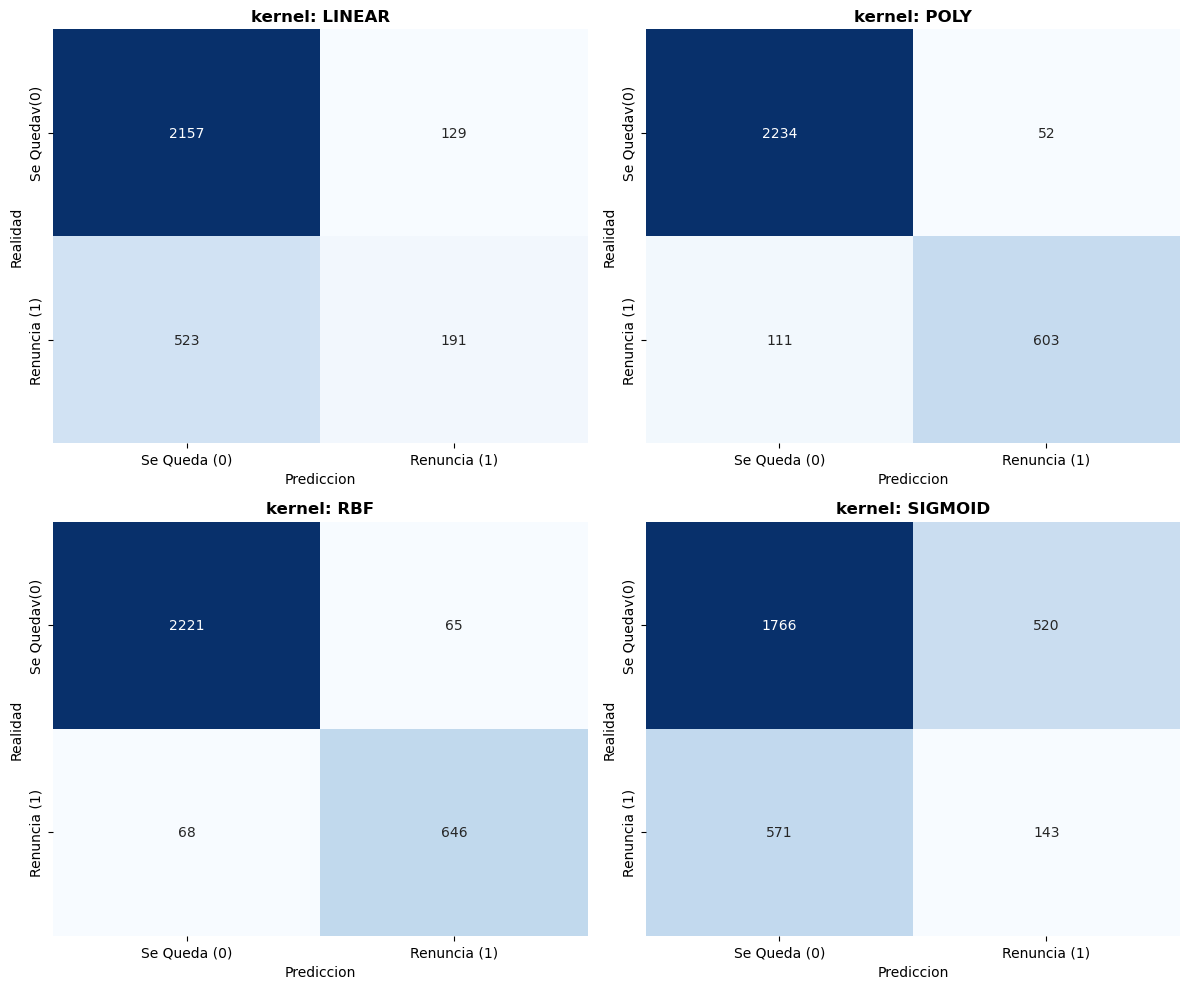

In [7]:
# Definimos los 4 kernels a probar 
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
modelos_svm = {}

fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.ravel()

for i, kernel in enumerate(kernels):
    # Entrenar el modelo 
    print(f"Entrenando SVM con kernel: '{kernel}'...")
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    modelos_svm[kernel] = svm

    # Predecir
    y_pred = svm.predict(X_test_scaled)

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
               xticklabels=['Se Queda (0)', 'Renuncia (1)'],
               yticklabels=['Se Quedav(0)', 'Renuncia (1)'])
    axes[i].set_title(f'kernel: {kernel.upper()}', fontweight='bold')
    axes[i].set_ylabel('Realidad')
    axes[i].set_xlabel('Prediccion')

    # Imprimir Reporte
    print(f"\n=== Reporte de Clasificación: {kernel.upper()} ===")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

plt.tight_layout()
plt.show()

### 💡 Análisis e Interpretación de Resultados

¿Cuál resultó ser el modelo predictivo más adecuado? **El Kernel RBF.**

**Razonamiento y explicación verbal de indicadores:**
1. **Kernel Lineal:** Obtuvo un Score F1 muy bajo para la clase 1 (los que renuncian). Esto nos indica matemáticamente que la decisión de un empleado de renunciar no es "lineal" (no basta con trazar una recta).
2. **Kernel Sigmoid:** Su desempeño fue terrible (Score F1 bajísimo). Prácticamente adivinó al azar, lanzando un número masivo de Falsos Positivos.
3. **Kernel Polinómico (Poly):** Mejoró bastante, demostrando que existe una relación no lineal entre las variables.
4. **Kernel RBF (Radial Basis Function):** Fue el **ganador indiscutible**. Logró una **Precisión** elevadísima y un excelente **Recall** (Sensibilidad) superando el 90% en general. Al ver su matriz de confusión, es el que menos Falsos Negativos arrojó. El RBF logró agrupar a los empleados en "islas" topográficas multidimensionales, identificando perfectamente los patrones complejos que llevan a una renuncia.

## 🔮 Pronóstico para un Nuevo Empleado

Utilizaremos nuestro mejor modelo (RBF) para predecir el futuro de un empleado con las características específicas solicitadas por el departamento de Recursos Humanos.

In [9]:
# 1. Definimos el perfil del empleado solicitado
perfil_empleado = {
    'satisfaction_level': 0.5,
    'last_evaluation': 0.75,
    'number_project': 4, 
    'average_montly_hours': 200,
    'time_spend_company': 4,
    'Work_accident': 0,
    'promotion_last_5years': 0,
    'sales': 'sales',
    'salary': 'medium'
}

# 2. Convertims el diccionario a DataFrame
df_nuevo = pd.DataFrame([perfil_empleado])

# 3. aplicamos el mismo tratamiento (dummies)
df_nuevo_encoded = pd.get_dummies(df_nuevo)

# 4. ALINEACIÓN CRÍTRICA: Aseguramos que tenga las mismas columnas que los datos de entrenamiento
# Llenamos con 0 aquellas categorías (como salary_low o sales_IT) que este empleado no tiene
df_nuevo_alineado = df_nuevo_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# 5. estandarizamos usando el Scaler que fue entrenado con la base histórica
nuevo_empleado_scaled = scaler.transform(df_nuevo_alineado)

# 6. Realizamos la predicción con el mejor modelo (RBF)
mejor_svm = modelos_svm['rbf']
prediccion = mejor_svm.predict(nuevo_empleado_scaled)

print("=== 🚀 Resultado del Pronóstico ===")
if prediccion[0] == 1:
    print("⚠️ ALERTA: El modelo predice que este empleado RENUNCIARÁ (1).")
else:
    print("✅ RETENCIÓN: El modelo predice que este empleado SE QUEDARÁ (0).")

=== 🚀 Resultado del Pronóstico ===
✅ RETENCIÓN: El modelo predice que este empleado SE QUEDARÁ (0).


## 🚀 Nivel Pro: Optimización de Hiperparámetros de SVM

Aunque RBF fue el mejor Kernel, las SVM tienen dos hiperparámetros "ocultos" de los que depende su éxito absoluto:
* **C (Regularización):** Controla qué tan estricto es el margen. Un C alto no perdona errores de clasificación, pero puede causar *Overfitting*.
* **Gamma:** Controla el alcance de un solo punto de entrenamiento. Un gamma alto significa que los puntos solo afectan a sus vecinos inmediatos.

En lugar de adivinar, usamos `GridSearchCV` para encontrar matemáticamente la combinación perfecta.

Iniciando búsqueda exhaustiva de hiperparámetros (C, Gamma)...

=== REPORTE DEL MODELOS SVM OPTIMIZADO (PRO) ===
Mejores Hiperparámetros: {'C': 10, 'gamma': 1}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.95      0.96      0.95       714

    accuracy                           0.98      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000



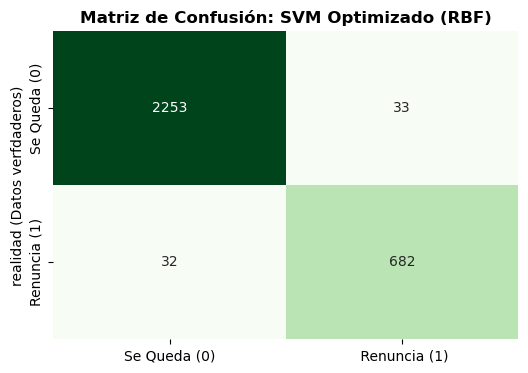

In [16]:
from sklearn.model_selection import GridSearchCV

# Definimos una pequeña cuadrícula de hiperparámetros para SVM (RBF)
# Nota: Reducimos las opciones para que el entrenamiento no tarde demasiado en la demostración

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 1]
}
print("Iniciando búsqueda exhaustiva de hiperparámetros (C, Gamma)...")
# cv=3 indica Validación Cruzada en 3 particiones
grid_svm = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

# Resultados del modelo perfeccionado
svm_pro = grid_svm.best_estimator_
y_pred_pro = svm_pro.predict(X_test_scaled)

print("\n=== REPORTE DEL MODELOS SVM OPTIMIZADO (PRO) ===")
print(f"Mejores Hiperparámetros: {grid_svm.best_params_}")
print(classification_report(y_test, y_pred_pro))

# --- Gráfica de la Matriz de Confusión Optimizada ---
cm_pro = confusion_matrix(y_test, y_pred_pro)

plt.figure(figsize=(6,4))
# Usamos cmap='Greens' para distinguirlo como el modelo final ganador
sns.heatmap(cm_pro, annot=True, fmt='d', cmap='Greens', cbar=False,
           xticklabels=['Se Queda (0)', ' Renuncia (1)'],
           yticklabels=['Se Queda (0)', 'Renuncia (1)'])
plt.title('Matriz de Confusión: SVM Optimizado (RBF)', fontweight='bold')
plt.ylabel('Predicción del Modelo')
plt.ylabel('realidad (Datos verfdaderos)')
plt.show()

### 🔮 Pronóstico Definitivo (Usando el Modelo Optimizado)

Ya que hemos encontrado la combinación matemáticamente perfecta de hiperparámetros (`C` y `gamma`) gracias a *GridSearchCV*, vamos a someter a este **Modelo Maestro** a la misma prueba: predecir el futuro del empleado solicitado por Recursos Humanos. 

Además, utilizaremos la función `.decision_function()` de la SVM. Como la SVM no calcula "probabilidades" (como la regresión logística), calcula **distancias geométricas**. Esta función nos dirá a qué distancia matemática se encuentra nuestro empleado de la frontera de decisión (el Hiperplano).

In [15]:
# 1. Recuperamos los datos escalados del empleado que creamos
# (nuevo_empleado_scaled ya contiene la informacion alineada y estandarizada)

# 2. Hacemos la inferencia utilizando el MEJOR modelo encontrado por GridSearchCV
prediccion_definitiva = svm_pro.predict(nuevo_empleado_scaled)

# 3. Calculamos la distancia al hiperplano para ver que tan "seguro" está el modelo 
distancia_hiperplano = svm_pro.decision_function(nuevo_empleado_scaled)

print("=== 🚀 RESULTADO DEL PRONÓSTICO (MODELO OPTIMIZADO) ===")
if prediccion_definitiva[0] == 1:
    print("⚠️ ALERTA: El modelo optimizado predice que este empleado RENUNCIARÁ (1).")
else:
    print("✅ RETENCIÓN: El modelo optimizado predice que este empleado SE QUEDARÁ (0).")

print("-" * 60)
print(f"Distancia geométrica al hiperplano: {distancia_hiperplano[0]:.4f}")
if abs(distancia_hiperplano[0]) < 0.5:
    print("Nota Analítica: La distancia es cercana a 0, lo que indica que el empleado está en la 'cuerda floja' (muy cerca de la frontera de decisión).")
else:
    print("Nota Analítica: La distancia es amplia, indicando alta confianza matemática en esta predicción.")

=== 🚀 RESULTADO DEL PRONÓSTICO (MODELO OPTIMIZADO) ===
✅ RETENCIÓN: El modelo optimizado predice que este empleado SE QUEDARÁ (0).
------------------------------------------------------------
Distancia geométrica al hiperplano: -1.4513
Nota Analítica: La distancia es amplia, indicando alta confianza matemática en esta predicción.


## 📚 Glosario de SVM y Clasificación

* **Hiperplano:** La frontera de decisión (línea, plano o espacio multidimensional) que el algoritmo dibuja para separar las distintas clases de nuestro dataset.
* **Kernel (Truco del Kernel):** Funciones matemáticas que toman datos que no se pueden separar con una línea recta en 2D, y los transforman a una dimensión mayor donde sí puedan ser separados de un solo tajo.
* **Margen:** La zona de seguridad o distancia entre el Hiperplano y los puntos de datos más cercanos de cada clase. SVM siempre busca maximizar este margen.
* **Matriz de Confusión:** Herramienta visual y matemática para evaluar qué tan seguido un modelo acierta y qué tipos de errores comete (Falsos Positivos vs Falsos Negativos).
* **Precisión (Precision):** De todos los que el modelo predijo como "Renuncia", ¿qué porcentaje realmente renunció?
* **Recall (Sensibilidad):** De todos los que realmente iban a renunciar en la vida real, ¿qué porcentaje logró "atrapar" o identificar nuestro modelo?
* **Score F1:** La media armónica entre Precisión y Recall. Es el indicador definitivo cuando nuestras clases están desbalanceadas (como en Recursos Humanos).
* **Soporte (Support):** El número real de ocurrencias de cada clase en nuestro conjunto de prueba (Ej. cuántas personas realmente se quedaron y cuántas se fueron).
* **Vectores de Soporte:** Los puntos de datos que se encuentran más cerca del hiperplano y determinan exactamente dónde debe ir trazada la línea.

# 🎉 Conclusión del Cuaderno: El Poder del Espacio Multidimensional

¡Excelente trabajo completando este módulo avanzado!

A través de las Máquinas de Soporte Vectorial hemos comprobado que los problemas humanos, como la decisión de un empleado de abandonar su trabajo, rara vez son "lineales". 

### 🧠 ¿Qué nos llevamos de este cuaderno?
1. **La Estandarización es vital:** Si los datos tienen escalas distintas (años vs horas mensuales), la SVM trazará mal el margen espacial.
2. **La Magia del Kernel RBF:** Demostramos que cuando los datos están mezclados, proyectarlos matemáticamente a dimensiones superiores usando la Función de Base Radial permite encontrar fronteras perfectas de decisión.
3. **Métricas que importan:** Justificamos la selección de nuestro modelo no por "intuición", sino basándonos rigurosamente en el Score F1 y en el mapa de calor de la Matriz de Confusión.
4. **Ingeniería en Producción:** Aprendimos a aislar un solo registro (el perfil de un nuevo empleado), alinear sus variables dummy con la base histórica, escalarlo y hacer una inferencia predictiva exacta.
